In [143]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [144]:
sns.set_style("whitegrid")

plt.rcParams.update({
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.spines.right':  False,
    'axes.spines.top':    False,
    'axes.grid':          True,
    'grid.color':         "#E8E8E8",   # почти белая сетка
    'grid.linewidth':     1,
})

In [145]:
df = pd.read_csv('dataset_for_dano_fuel.csv')

In [146]:
df

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,entries_cnt,region,gender_cd,age,education_level_cd,marital_status_cd,children_cnt,job_title
0,2025-05-04 21:00:00+00:00,1038898430,23,3299.69,1.0,Pro,6.0,WEBVIEW_IOS,51.89,2025-03-03,1.0,NaN,M,29.0,NaN,UNM,0.0,Пожарный
1,2025-05-18 21:00:00+00:00,645418085,0,197.80,1.0,No Subscription,6.0,ANDROID,3.63,2024-02-08,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-06 21:00:00+00:00,157611917,23,4035.71,1.0,Premium,7.0,IOS,61.52,2025-03-07,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-05-18 21:00:00+00:00,610595698,23,1300.71,1.0,No Subscription,3.0,ANDROID,23.47,2024-03-03,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-13 21:00:00+00:00,1076685894,49,507.77,1.0,Pro,0.0,WEBVIEW_ANDROID,8.84,2025-01-31,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448127,2025-04-27 21:00:00+00:00,1045147678,0,2459.88,1.0,Pro,3.0,WEBVIEW_ANDROID,41.51,2024-01-11,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
448128,2025-05-11 21:00:00+00:00,156272039,0,1828.50,1.0,No Subscription,0.0,ANDROID,30.00,2023-03-09,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
448129,2025-03-30 21:00:00+00:00,537008984,23,2275.19,1.0,No Subscription,0.0,ANDROID,40.00,2023-02-08,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
448130,2025-05-25 21:00:00+00:00,956839671,0,2003.87,1.0,Pro,0.0,WEBVIEW_ANDROID,32.17,2023-08-10,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [147]:
mean_price = (df[df['liters'] != 0]['gmv'] / df[df['liters'] != 0]['liters']).mean()
df.loc[df['liters'] == 0, 'liters'] = df.loc[df['liters'] == 0, 'gmv'] / mean_price

In [148]:
df['mean_price'] = df.gmv / df.orders_cnt

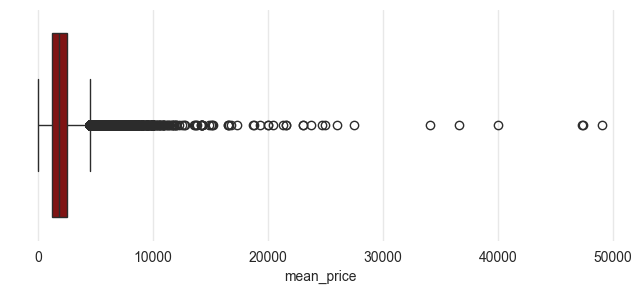

In [149]:

# Сначала создаём фигуру нужного размера
plt.figure(figsize=(8, 3))          # вот здесь размер

# Потом рисуем boxplot
sns.boxplot(x=df['mean_price'], color='#910202')

plt.show()

In [150]:
df = df[(df['liters'] / df['orders_cnt'] <= 300) & (df['liters'] / df['orders_cnt'] >= 2)]

In [151]:
df

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,entries_cnt,region,gender_cd,age,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price
0,2025-05-04 21:00:00+00:00,1038898430,23,3299.69,1.0,Pro,6.0,WEBVIEW_IOS,51.89,2025-03-03,1.0,NaN,M,29.0,NaN,UNM,0.0,Пожарный,3299.69
1,2025-05-18 21:00:00+00:00,645418085,0,197.80,1.0,No Subscription,6.0,ANDROID,3.63,2024-02-08,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,197.80
2,2025-04-06 21:00:00+00:00,157611917,23,4035.71,1.0,Premium,7.0,IOS,61.52,2025-03-07,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4035.71
3,2025-05-18 21:00:00+00:00,610595698,23,1300.71,1.0,No Subscription,3.0,ANDROID,23.47,2024-03-03,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1300.71
4,2025-04-13 21:00:00+00:00,1076685894,49,507.77,1.0,Pro,0.0,WEBVIEW_ANDROID,8.84,2025-01-31,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,507.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448127,2025-04-27 21:00:00+00:00,1045147678,0,2459.88,1.0,Pro,3.0,WEBVIEW_ANDROID,41.51,2024-01-11,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2459.88
448128,2025-05-11 21:00:00+00:00,156272039,0,1828.50,1.0,No Subscription,0.0,ANDROID,30.00,2023-03-09,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1828.50
448129,2025-03-30 21:00:00+00:00,537008984,23,2275.19,1.0,No Subscription,0.0,ANDROID,40.00,2023-02-08,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2275.19
448130,2025-05-25 21:00:00+00:00,956839671,0,2003.87,1.0,Pro,0.0,WEBVIEW_ANDROID,32.17,2023-08-10,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003.87


In [152]:
df['meanperliter'] = df['gmv']/df['liters']

C:\Users\darak\AppData\Local\Temp\ipykernel_44988\1982014600.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['meanperliter'] = df['gmv']/df['liters']


<Axes: xlabel='meanperliter'>

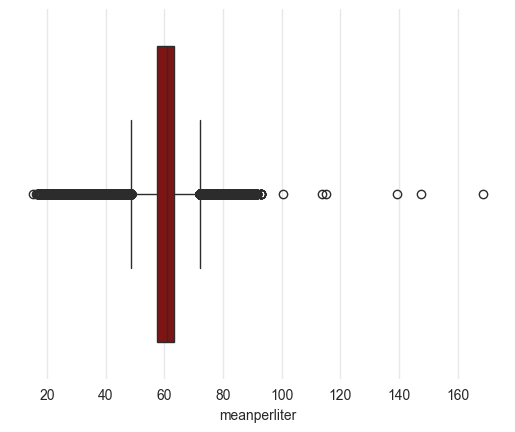

In [153]:
sns.boxplot(x=df['meanperliter'], color='#910202')

In [154]:
df = df[df['meanperliter'] < 94]

<Axes: xlabel='mean_price'>

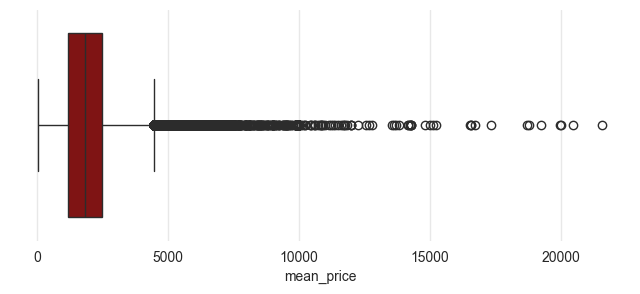

In [155]:
plt.figure(figsize=(8, 3))          # вот здесь размер

# Потом рисуем boxplot
sns.boxplot(x=df['mean_price'], color='#910202')

In [156]:
df[df['mean_price'] > 16000]

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,entries_cnt,region,gender_cd,age,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price,meanperliter
3847,2025-05-18 21:00:00+00:00,998128449,0,40919.62,2.0,No Subscription,5.0,ANDROID,552.67,2025-04-02,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20459.810000,74.039879
13256,2025-05-11 21:00:00+00:00,960792088,19,17330.00,1.0,Premium,4.0,IOS,250.00,2025-04-12,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17330.000000,69.320000
30113,2025-05-04 21:00:00+00:00,731960169,23,18798.56,1.0,Pro,4.0,IOS,242.00,2025-04-02,2.0,NaN,M,39.0,SCH,MAR,0.0,Собственный официальный бизнес,18798.560000,77.680000
101293,2025-05-11 21:00:00+00:00,223244309,0,198995.48,12.0,No Subscription,0.0,ANDROID,2702.68,2024-11-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16582.956667,73.628946
110196,2025-04-13 21:00:00+00:00,340611341,19,19260.00,1.0,No Subscription,3.0,ANDROID,300.00,2024-10-12,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19260.000000,64.200000
156096,2025-04-06 21:00:00+00:00,627033051,29,16560.00,1.0,Premium,19.0,IOS,240.00,2025-04-01,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16560.000000,69.000000
224754,2025-05-04 21:00:00+00:00,1195280495,19,19989.55,1.0,Pro,17.0,ANDROID,287.00,2025-05-10,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19989.550000,69.650000
236911,2025-04-06 21:00:00+00:00,393050355,23,19999.89,1.0,Premium,3.0,IOS,292.91,2022-04-15,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999.890000,68.279984
249236,2025-04-20 21:00:00+00:00,1217898261,0,56194.22,3.0,No Subscription,0.0,ANDROID,804.33,2025-03-05,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18731.406667,69.864633
312693,2025-05-11 21:00:00+00:00,610567653,19,21576.00,1.0,No Subscription,14.0,WEBVIEW_ANDROID,300.00,2025-04-27,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21576.000000,71.920000


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 448035 entries, 0 to 448131
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   week                448035 non-null  object 
 1   party_rk            448035 non-null  int64  
 2   service_fee_amt     448035 non-null  int64  
 3   gmv                 448035 non-null  float64
 4   orders_cnt          448035 non-null  float64
 5   bundle_name         448035 non-null  object 
 6   cashback_category   448035 non-null  float64
 7   platform            448035 non-null  object 
 8   liters              448035 non-null  float64
 9   first_order_date    448035 non-null  object 
 10  entries_cnt         442679 non-null  float64
 11  region              0 non-null       float64
 12  gender_cd           128179 non-null  object 
 13  age                 128268 non-null  float64
 14  education_level_cd  65320 non-null   object 
 15  marital_status_cd   77092 non-null   ob

In [158]:
df['week'] = pd.to_datetime(df['week'])
df['fisrt_order_date'] = pd.to_datetime(df['first_order_date'])

C:\Users\darak\AppData\Local\Temp\ipykernel_44988\756500679.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['week'] = pd.to_datetime(df['week'])
C:\Users\darak\AppData\Local\Temp\ipykernel_44988\756500679.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fisrt_order_date'] = pd.to_datetime(df['first_order_date'])


In [159]:
df

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,region,gender_cd,age,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date
0,2025-05-04 21:00:00+00:00,1038898430,23,3299.69,1.0,Pro,6.0,WEBVIEW_IOS,51.89,2025-03-03,...,NaN,M,29.0,NaN,UNM,0.0,Пожарный,3299.69,63.590094,2025-03-03
1,2025-05-18 21:00:00+00:00,645418085,0,197.80,1.0,No Subscription,6.0,ANDROID,3.63,2024-02-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,197.80,54.490358,2024-02-08
2,2025-04-06 21:00:00+00:00,157611917,23,4035.71,1.0,Premium,7.0,IOS,61.52,2025-03-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4035.71,65.599967,2025-03-07
3,2025-05-18 21:00:00+00:00,610595698,23,1300.71,1.0,No Subscription,3.0,ANDROID,23.47,2024-03-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1300.71,55.420111,2024-03-03
4,2025-04-13 21:00:00+00:00,1076685894,49,507.77,1.0,Pro,0.0,WEBVIEW_ANDROID,8.84,2025-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,507.77,57.440045,2025-01-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448127,2025-04-27 21:00:00+00:00,1045147678,0,2459.88,1.0,Pro,3.0,WEBVIEW_ANDROID,41.51,2024-01-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2459.88,59.259937,2024-01-11
448128,2025-05-11 21:00:00+00:00,156272039,0,1828.50,1.0,No Subscription,0.0,ANDROID,30.00,2023-03-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1828.50,60.950000,2023-03-09
448129,2025-03-30 21:00:00+00:00,537008984,23,2275.19,1.0,No Subscription,0.0,ANDROID,40.00,2023-02-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2275.19,56.879750,2023-02-08
448130,2025-05-25 21:00:00+00:00,956839671,0,2003.87,1.0,Pro,0.0,WEBVIEW_ANDROID,32.17,2023-08-10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003.87,62.290022,2023-08-10


C:\Users\darak\AppData\Local\Temp\ipykernel_44988\2095443511.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


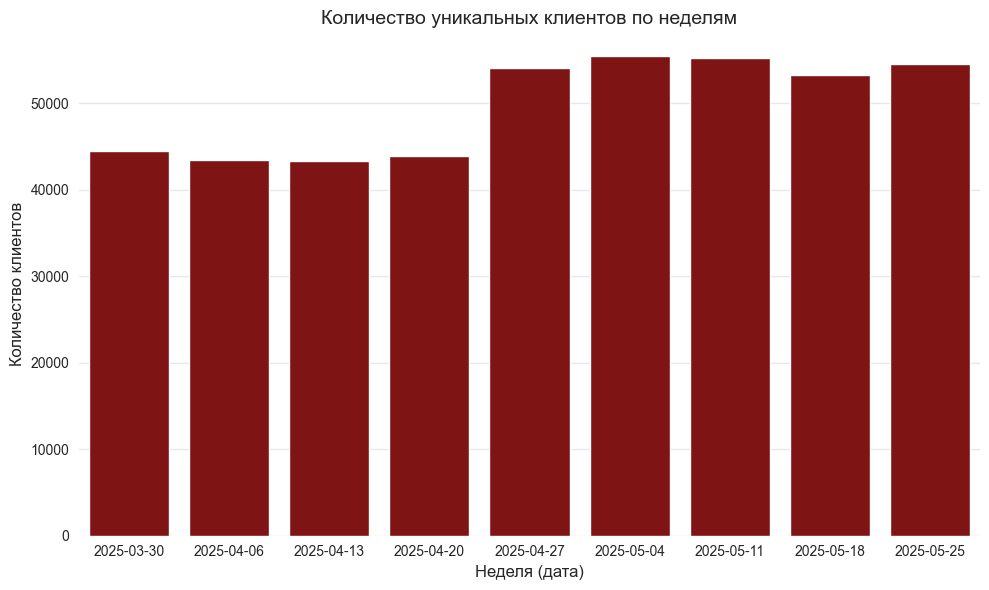

In [160]:

clients_per_week = (
    df.groupby('week')['party_rk']
    .nunique()
    .reset_index()
    .rename(columns={'party_rk': 'unique_clients'})
)

clients_per_week = clients_per_week.sort_values('week')

week_dates = pd.to_datetime(clients_per_week['week']).dt.date

# Строим график
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=clients_per_week,
                 x=week_dates,
                 y='unique_clients',
                 color='#910202')

ax.grid(True, axis='y', linestyle='-', alpha=1, linewidth=1)

# Красивые метки оси X: ГГГГ-ММ-ДД
ax.set_xticklabels(
    [d.strftime('%Y-%m-%d') for d in week_dates]
)

plt.title('Количество уникальных клиентов по неделям', fontsize=14)
plt.xlabel('Неделя (дата)', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.tight_layout()
plt.show()

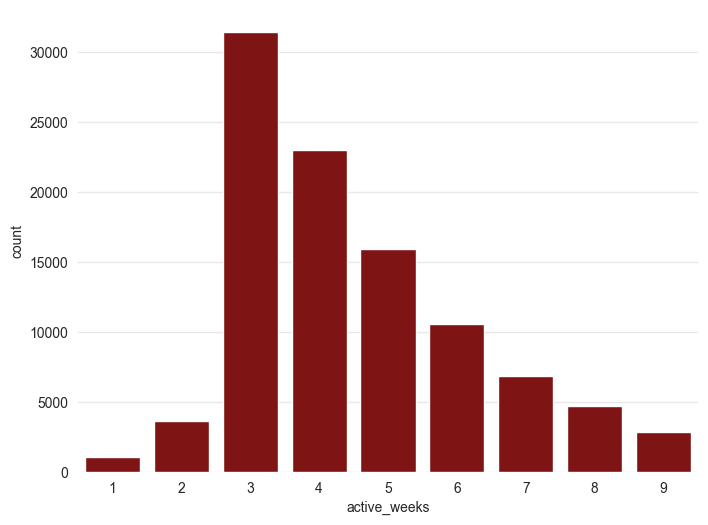

In [161]:

active_weeks = (
    df.groupby('party_rk')['week']
    .nunique()
    .reset_index()
    .rename(columns={'week': 'active_weeks'})
)

plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=active_weeks,
    x='active_weeks',
    color='#910202'
)

ax.grid(True, axis='y', linestyle='-', alpha=1, linewidth=1)

plt.show()


In [162]:
df

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,region,gender_cd,age,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date
0,2025-05-04 21:00:00+00:00,1038898430,23,3299.69,1.0,Pro,6.0,WEBVIEW_IOS,51.89,2025-03-03,...,NaN,M,29.0,NaN,UNM,0.0,Пожарный,3299.69,63.590094,2025-03-03
1,2025-05-18 21:00:00+00:00,645418085,0,197.80,1.0,No Subscription,6.0,ANDROID,3.63,2024-02-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,197.80,54.490358,2024-02-08
2,2025-04-06 21:00:00+00:00,157611917,23,4035.71,1.0,Premium,7.0,IOS,61.52,2025-03-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4035.71,65.599967,2025-03-07
3,2025-05-18 21:00:00+00:00,610595698,23,1300.71,1.0,No Subscription,3.0,ANDROID,23.47,2024-03-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1300.71,55.420111,2024-03-03
4,2025-04-13 21:00:00+00:00,1076685894,49,507.77,1.0,Pro,0.0,WEBVIEW_ANDROID,8.84,2025-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,507.77,57.440045,2025-01-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448127,2025-04-27 21:00:00+00:00,1045147678,0,2459.88,1.0,Pro,3.0,WEBVIEW_ANDROID,41.51,2024-01-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2459.88,59.259937,2024-01-11
448128,2025-05-11 21:00:00+00:00,156272039,0,1828.50,1.0,No Subscription,0.0,ANDROID,30.00,2023-03-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1828.50,60.950000,2023-03-09
448129,2025-03-30 21:00:00+00:00,537008984,23,2275.19,1.0,No Subscription,0.0,ANDROID,40.00,2023-02-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2275.19,56.879750,2023-02-08
448130,2025-05-25 21:00:00+00:00,956839671,0,2003.87,1.0,Pro,0.0,WEBVIEW_ANDROID,32.17,2023-08-10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003.87,62.290022,2023-08-10


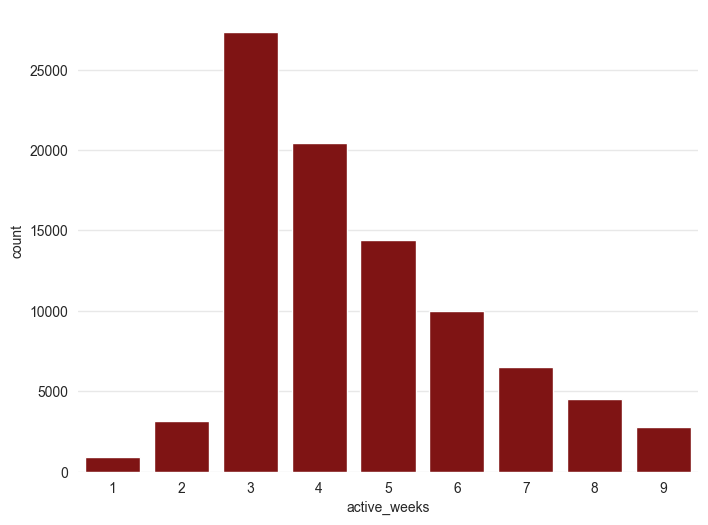

In [163]:

active_weeks2 = (
    df[df['first_order_date'] <= '2025-03-30'].groupby('party_rk')['week']
    .nunique()
    .reset_index()
    .rename(columns={'week': 'active_weeks'})
)

plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=active_weeks2,
    x='active_weeks',
    color='#910202'
)

ax.grid(True, axis='y', linestyle='-', alpha=1, linewidth=1)

plt.show()

In [164]:
active_weeks2['active_weeks'].median()

np.float64(4.0)

In [165]:
active_weeks2['active_weeks'].mode()

0    3
Name: active_weeks, dtype: int64

In [166]:
df

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,region,gender_cd,age,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date
0,2025-05-04 21:00:00+00:00,1038898430,23,3299.69,1.0,Pro,6.0,WEBVIEW_IOS,51.89,2025-03-03,...,NaN,M,29.0,NaN,UNM,0.0,Пожарный,3299.69,63.590094,2025-03-03
1,2025-05-18 21:00:00+00:00,645418085,0,197.80,1.0,No Subscription,6.0,ANDROID,3.63,2024-02-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,197.80,54.490358,2024-02-08
2,2025-04-06 21:00:00+00:00,157611917,23,4035.71,1.0,Premium,7.0,IOS,61.52,2025-03-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4035.71,65.599967,2025-03-07
3,2025-05-18 21:00:00+00:00,610595698,23,1300.71,1.0,No Subscription,3.0,ANDROID,23.47,2024-03-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1300.71,55.420111,2024-03-03
4,2025-04-13 21:00:00+00:00,1076685894,49,507.77,1.0,Pro,0.0,WEBVIEW_ANDROID,8.84,2025-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,507.77,57.440045,2025-01-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448127,2025-04-27 21:00:00+00:00,1045147678,0,2459.88,1.0,Pro,3.0,WEBVIEW_ANDROID,41.51,2024-01-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2459.88,59.259937,2024-01-11
448128,2025-05-11 21:00:00+00:00,156272039,0,1828.50,1.0,No Subscription,0.0,ANDROID,30.00,2023-03-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1828.50,60.950000,2023-03-09
448129,2025-03-30 21:00:00+00:00,537008984,23,2275.19,1.0,No Subscription,0.0,ANDROID,40.00,2023-02-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2275.19,56.879750,2023-02-08
448130,2025-05-25 21:00:00+00:00,956839671,0,2003.87,1.0,Pro,0.0,WEBVIEW_ANDROID,32.17,2023-08-10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003.87,62.290022,2023-08-10


In [167]:
import pandas as pd

# Assuming df is your DataFrame and 'week' is the column with week start dates
# Make sure 'week' is datetime type
df['week'] = pd.to_datetime(df['week'])

# Find the last week (assuming it's the maximum week in the dataset)
last_week = df['week'].max()
# If you know it's specifically '2025-05-25', you can set:
# last_week = pd.to_datetime('2025-05-25')

# Sort the DataFrame by user (party_rk) and week
df = df.sort_values(['party_rk', 'week'])

# Compute the next week for each user
df['next_week'] = df.groupby('party_rk')['week'].shift(-1)

# Compute the weeks to next (as integer)
df['weeks_to_next'] = (df['next_week'] - df['week']).dt.days // 7

# Now, create the series for all rows except those in the last week
series = df[df['week'] < last_week]['weeks_to_next'].reset_index(drop=True)

# If you want it as a pandas Series without the index from df
print(series)

C:\Users\darak\AppData\Local\Temp\ipykernel_44988\1981502846.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['week'] = pd.to_datetime(df['week'])


0         2.0
1         3.0
2         1.0
3         1.0
4         1.0
         ... 
393430    1.0
393431    3.0
393432    2.0
393433    2.0
393434    NaN
Name: weeks_to_next, Length: 393435, dtype: float64


      Квантиль  Недель до возврата
0.05      0.05                 1.0
0.10      0.10                 1.0
0.25      0.25                 1.0
0.50      0.50                 1.0
0.75      0.75                 2.0
0.90      0.90                 3.0
0.95      0.95                 4.0
0.99      0.99                 5.0


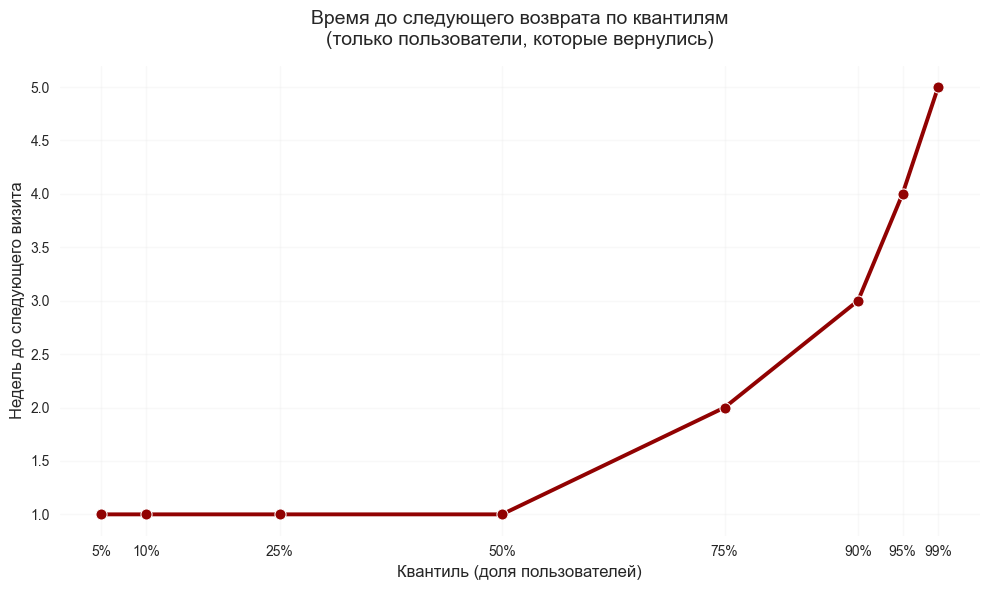

In [168]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Предполагаем, что series уже создан (как в предыдущем коде)
# Если нужно — сначала выполните код из прошлого сообщения

# Квантили
quantiles = np.array([0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
q_values = series.quantile(quantiles)

# Таблица
quantile_table = pd.DataFrame({
    'Квантиль': quantiles,
    'Недель до возврата': q_values.round(1)
})
print(quantile_table)

# График
plt.figure(figsize=(10, 6))

# Линия и точки нужного цвета
sns.lineplot(x=quantiles, y=q_values, 
             marker='o', markersize=8, linewidth=2.8, 
             color='#910202')

# Без подписей значений над точками
plt.title('Время до следующего возврата по квантилям\n(только пользователи, которые вернулись)', fontsize=14, pad=15)
plt.xlabel('Квантиль (доля пользователей)', fontsize=12)
plt.ylabel('Недель до следующего визита', fontsize=12)
plt.xticks(quantiles, [f'{q*100:.0f}%' for q in quantiles])
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [169]:
series.quantile(0.92)

np.float64(3.0)

In [170]:
df['orders_cnt'] = df['orders_cnt'].astype('int')

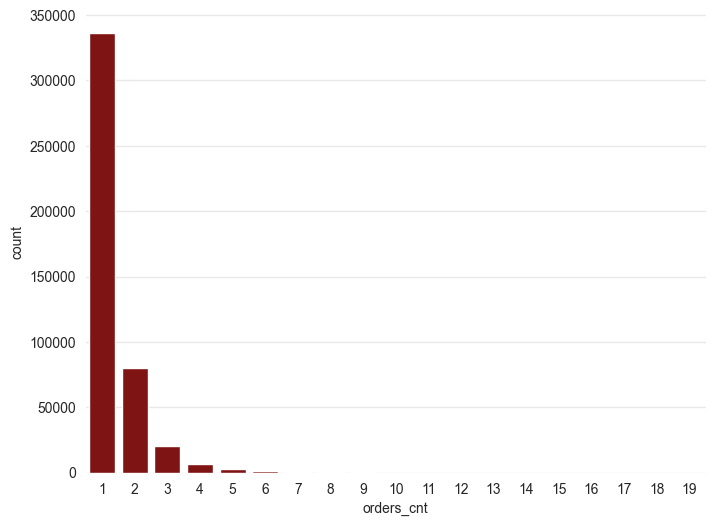

In [171]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df,
    x='orders_cnt',
    color='#910202'
)

ax.grid(True, axis='y', linestyle='-', alpha=1, linewidth=1)

plt.show()

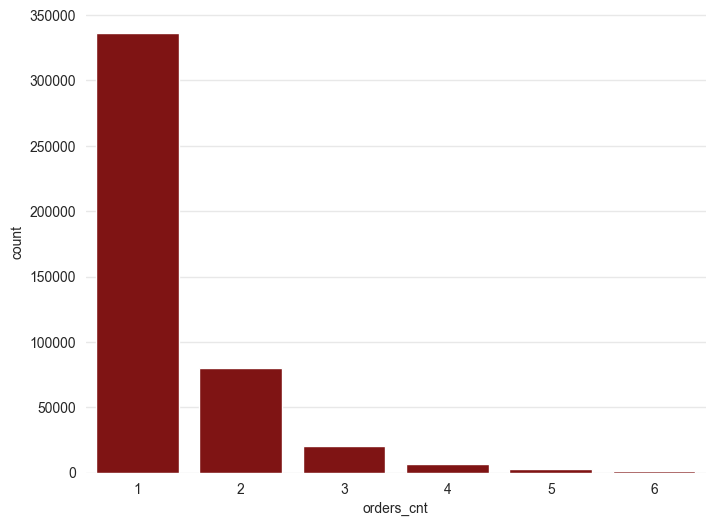

In [172]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df[df['orders_cnt'] <= 6],
    x='orders_cnt',
    color='#910202'
)

ax.grid(True, axis='y', linestyle='-', alpha=1, linewidth=1)

plt.show()

In [173]:
df[df['orders_cnt'] == 7]

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,age,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,next_week,weeks_to_next
184577,2025-04-13 21:00:00+00:00,1635034,29,9319.24,7,Pro,4.0,ANDROID,166.90,2025-02-05,...,NaN,NaN,NaN,NaN,NaN,1331.320000,55.837268,2025-02-05,2025-04-20 21:00:00+00:00,1.0
35776,2025-05-11 21:00:00+00:00,1635034,19,10268.21,7,Pro,3.0,ANDROID,183.31,2025-02-05,...,NaN,NaN,NaN,NaN,NaN,1466.887143,56.015547,2025-02-05,2025-05-18 21:00:00+00:00,1.0
401123,2025-05-18 21:00:00+00:00,1635034,19,10191.60,7,Pro,3.0,ANDROID,181.56,2025-02-05,...,NaN,NaN,NaN,NaN,NaN,1455.942857,56.133510,2025-02-05,2025-05-25 21:00:00+00:00,1.0
249681,2025-05-04 21:00:00+00:00,2709952,19,12559.76,7,Pro,3.0,ANDROID,226.39,2022-09-01,...,NaN,NaN,NaN,NaN,NaN,1794.251429,55.478422,2022-09-01,2025-05-11 21:00:00+00:00,1.0
295207,2025-05-11 21:00:00+00:00,3160759,19,4611.60,7,No Subscription,0.0,ANDROID,84.00,2023-08-23,...,NaN,NaN,NaN,NaN,NaN,658.800000,54.900000,2023-08-23,2025-05-18 21:00:00+00:00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9085,2025-05-04 21:00:00+00:00,1214204090,19,8744.94,7,No Subscription,12.0,WEBVIEW_IOS,143.68,2025-04-25,...,65.0,NaN,NaN,NaN,NaN,1249.277143,60.864003,2025-04-25,2025-05-11 21:00:00+00:00,1.0
337603,2025-05-11 21:00:00+00:00,1215530739,0,3422.94,7,No Subscription,4.0,WEB,115.62,2025-03-14,...,70.0,SCH,WID,0.0,NaN,488.991429,29.605086,2025-03-14,2025-05-18 21:00:00+00:00,1.0
412901,2025-05-18 21:00:00+00:00,1237708431,39,32208.70,7,Premium,3.0,WEBVIEW_IOS,450.69,2024-12-07,...,NaN,NaN,NaN,NaN,NaN,4601.242857,71.465309,2024-12-07,NaT,NaN
26369,2025-04-27 21:00:00+00:00,1332812089,19,5378.83,7,Pro,3.0,ANDROID,205.39,2024-03-08,...,NaN,NaN,NaN,NaN,NaN,768.404286,26.188373,2024-03-08,2025-05-04 21:00:00+00:00,1.0


In [174]:
len(df[df['orders_cnt'] == 1])/len(df)

0.7513408550671264

<Axes: xlabel='orders_cnt', ylabel='count'>

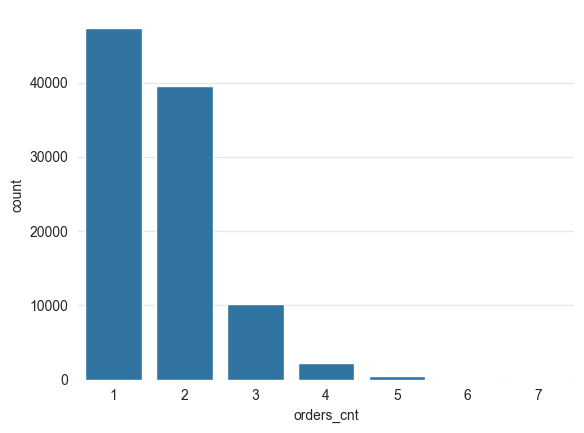

In [175]:
sns.countplot(x=df.groupby('party_rk').agg({'orders_cnt': 'nunique'})['orders_cnt'])

In [176]:
df[df['orders_cnt'] == 4]

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,age,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,next_week,weeks_to_next
265372,2025-04-27 21:00:00+00:00,601172,39,9447.90,4,Pro,5.0,WEBVIEW_IOS,160.00,2023-09-23,...,NaN,NaN,NaN,NaN,NaN,2361.9750,59.049375,2023-09-23,2025-05-04 21:00:00+00:00,1.0
13326,2025-05-25 21:00:00+00:00,753139,19,13070.71,4,Premium,0.0,ANDROID,191.96,2024-02-25,...,37.0,GRD,MAR,0.0,Собственный официальный бизнес,3267.6775,68.090800,2024-02-25,NaT,NaN
285597,2025-05-11 21:00:00+00:00,795281,19,7289.56,4,Premium,0.0,ANDROID,128.93,2023-06-15,...,NaN,NaN,NaN,NaN,NaN,1822.3900,56.538897,2023-06-15,2025-05-18 21:00:00+00:00,1.0
317176,2025-03-30 21:00:00+00:00,953838,0,7051.94,4,Premium,10.0,WEB,108.06,2025-04-03,...,NaN,NaN,NaN,NaN,NaN,1762.9850,65.259485,2025-04-03,2025-04-06 21:00:00+00:00,1.0
414117,2025-04-20 21:00:00+00:00,1090539,69,6611.29,4,No Subscription,0.0,ANDROID,115.82,2024-04-09,...,47.0,SCH,MAR,2.0,ОХРАННИК,1652.8225,57.082456,2024-04-09,2025-04-27 21:00:00+00:00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400274,2025-05-04 21:00:00+00:00,1349344144,0,8014.74,4,Premium,4.0,IOS,136.30,2023-07-30,...,NaN,NaN,NaN,NaN,NaN,2003.6850,58.802201,2023-07-30,2025-05-11 21:00:00+00:00,1.0
422343,2025-04-13 21:00:00+00:00,1350374899,23,4498.17,4,Pro,3.0,WEBVIEW_IOS,74.67,2023-10-25,...,NaN,NaN,NaN,NaN,NaN,1124.5425,60.240659,2023-10-25,2025-04-20 21:00:00+00:00,1.0
324924,2025-05-18 21:00:00+00:00,1351037181,23,6247.25,4,No Subscription,17.0,ANDROID,115.00,2025-05-14,...,NaN,NaN,NaN,NaN,NaN,1561.8125,54.323913,2025-05-14,2025-05-25 21:00:00+00:00,1.0
85470,2025-05-04 21:00:00+00:00,1352949919,29,4502.01,4,No Subscription,4.0,WEBVIEW_IOS,80.70,2025-01-15,...,NaN,NaN,NaN,NaN,NaN,1125.5025,55.786989,2025-01-15,2025-05-18 21:00:00+00:00,2.0


In [177]:
df[df['party_rk'] == 1046616704]

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,age,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,next_week,weeks_to_next
332973,2025-03-30 21:00:00+00:00,1046616704,23,2799.18,3,No Subscription,3.0,ANDROID,46.18,2024-12-21,...,NaN,NaN,NaN,NaN,NaN,933.060000,60.614552,2024-12-21,2025-04-06 21:00:00+00:00,1.0
448059,2025-04-06 21:00:00+00:00,1046616704,89,4498.92,4,No Subscription,3.0,ANDROID,74.90,2024-12-21,...,NaN,NaN,NaN,NaN,NaN,1124.730000,60.065688,2024-12-21,2025-04-13 21:00:00+00:00,1.0
154078,2025-04-13 21:00:00+00:00,1046616704,89,2999.48,2,No Subscription,3.0,ANDROID,49.18,2024-12-21,...,NaN,NaN,NaN,NaN,NaN,1499.740000,60.989833,2024-12-21,2025-04-20 21:00:00+00:00,1.0
355629,2025-04-20 21:00:00+00:00,1046616704,19,1499.70,1,No Subscription,3.0,ANDROID,22.74,2024-12-21,...,NaN,NaN,NaN,NaN,NaN,1499.700000,65.949868,2024-12-21,2025-04-27 21:00:00+00:00,1.0
419678,2025-04-27 21:00:00+00:00,1046616704,19,999.72,1,No Subscription,0.0,ANDROID,14.91,2024-12-21,...,NaN,NaN,NaN,NaN,NaN,999.720000,67.050302,2024-12-21,2025-05-04 21:00:00+00:00,1.0
107972,2025-05-04 21:00:00+00:00,1046616704,19,999.76,1,No Subscription,0.0,ANDROID,16.36,2024-12-21,...,NaN,NaN,NaN,NaN,NaN,999.760000,61.110024,2024-12-21,2025-05-11 21:00:00+00:00,1.0
69894,2025-05-11 21:00:00+00:00,1046616704,19,4999.21,3,No Subscription,0.0,ANDROID,82.44,2024-12-21,...,NaN,NaN,NaN,NaN,NaN,1666.403333,60.640587,2024-12-21,2025-05-25 21:00:00+00:00,2.0
289603,2025-05-25 21:00:00+00:00,1046616704,19,999.80,1,No Subscription,0.0,ANDROID,15.16,2024-12-21,...,NaN,NaN,NaN,NaN,NaN,999.800000,65.949868,2024-12-21,NaT,NaN


<Axes: xlabel='service_fee_amt', ylabel='count'>

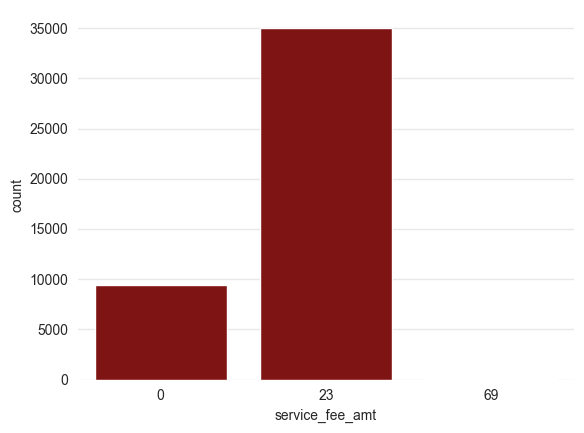

In [178]:
sns.countplot(x=df[df['week'] == '2025-03-30 21:00:00+00:00']['service_fee_amt'], color='#910202')

<Axes: xlabel='service_fee_amt', ylabel='count'>

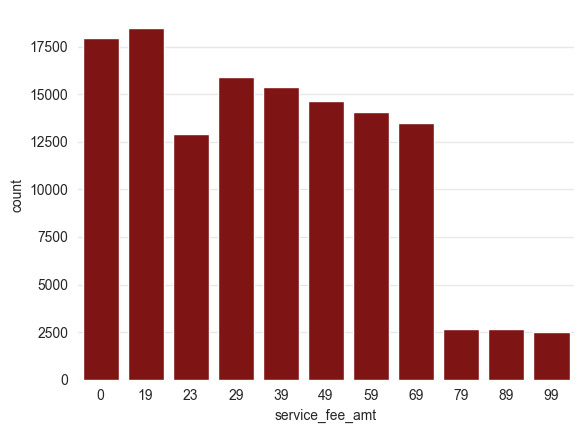

In [179]:
sns.countplot(x=df[(df['week'] > '2025-03-30 21:00:00+00:00') & (df['week'] < '2025-04-27 21:00:00+00:00')]['service_fee_amt'], color='#910202')

<Axes: xlabel='service_fee_amt', ylabel='count'>

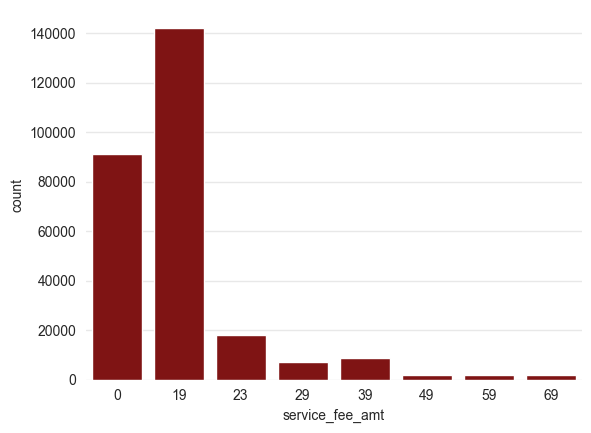

In [180]:
sns.countplot(x=df[(df['week'] >= '2025-04-27 21:00:00+00:00')]['service_fee_amt'], color='#910202')

<Axes: xlabel='service_fee_amt', ylabel='count'>

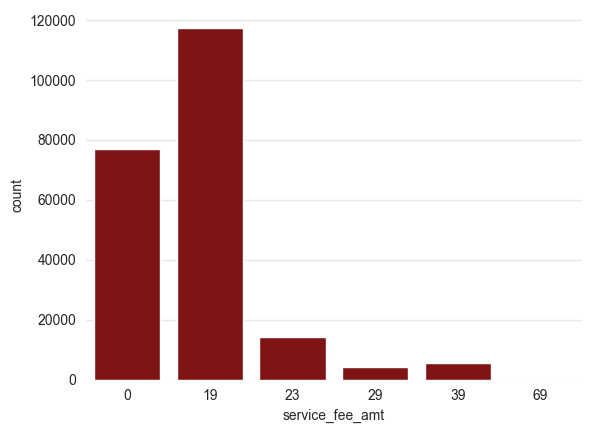

In [181]:
sns.countplot(x=df[(df['week'] > '2025-04-27 21:00:00+00:00')]['service_fee_amt'], color='#910202')

<Axes: xlabel='gmv'>

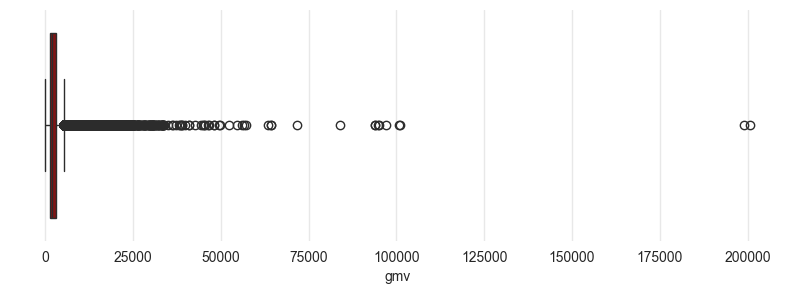

In [182]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['gmv'], color='#910202')

<Axes: xlabel='gmv', ylabel='Count'>

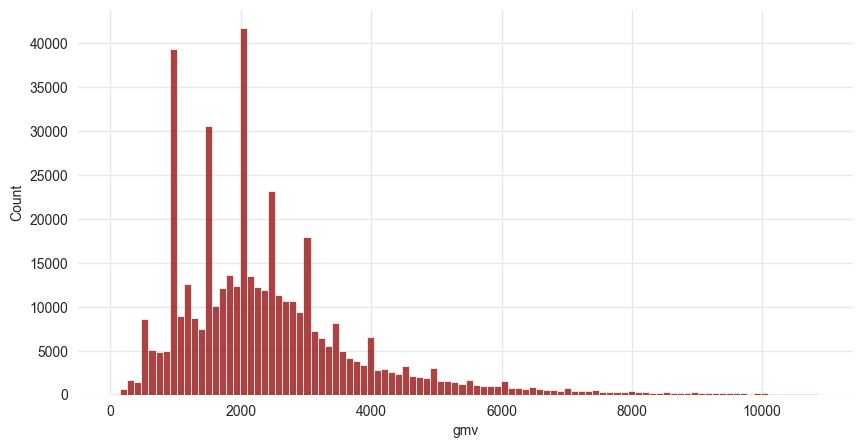

In [183]:
plt.figure(figsize=(10, 5))
sns.histplot(x=df[df['gmv'] < df['gmv'].quantile(0.995)]['gmv'], color='#910202', bins=100)

In [184]:
df['gmv'].mean()

np.float64(2504.477092236098)

In [185]:
df['gmv'].median()

np.float64(2086.0)

In [186]:
df['gmv'].std()

np.float64(1859.0408448765463)

In [187]:
df['proportion'] = (df['service_fee_amt'] * df['orders_cnt'])/df['gmv']

<Axes: xlabel='proportion'>

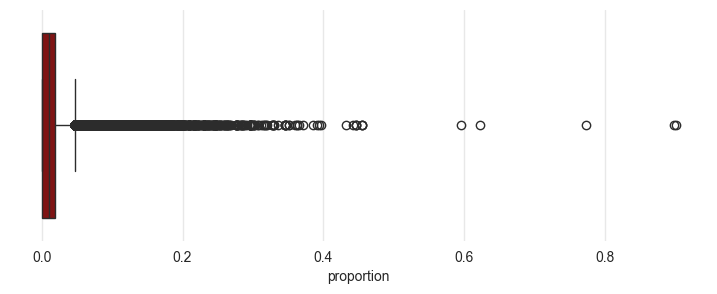

In [188]:
plt.figure(figsize=(9, 3))
sns.boxplot(x=df['proportion'], color='#910202')

<Axes: xlabel='proportion', ylabel='Count'>

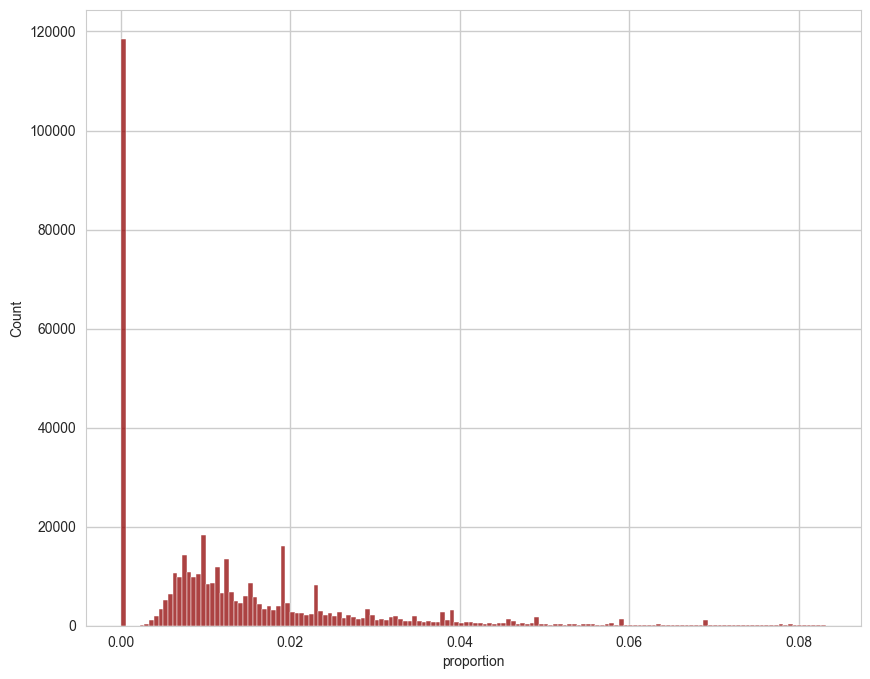

In [260]:
plt.figure(figsize=(10, 8))
sns.histplot(x=df[df['proportion'] < df['proportion'].quantile(0.99)]['proportion'], color='#910202', bins=150)

In [263]:
round(df['proportion'].median(), 5)

np.float64(0.01014)

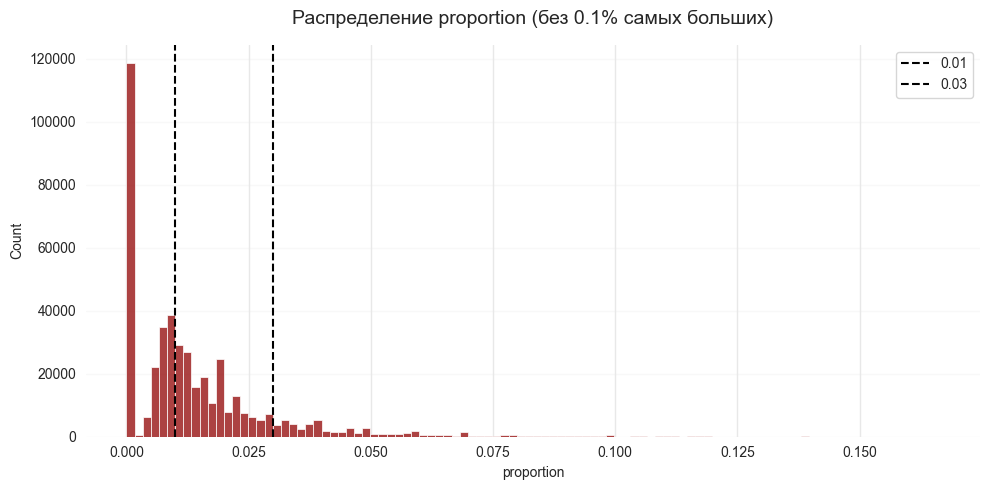

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns

# Твой исходный график (можно оставить как есть)
plt.figure(figsize=(10, 5))

# Гистограмма (твой код)
sns.histplot(
    x=df[df['proportion'] < df['proportion'].quantile(0.999)]['proportion'],
    color='#910202',
    bins=100
)

# Добавляем вертикальные линии
plt.axvline(x=0.01, color='black', linestyle='--', linewidth=1.5, label='0.01')
plt.axvline(x=0.03, color='black', linestyle='--', linewidth=1.5, label='0.03')

# Подписи и оформление
plt.xlabel('proportion')
plt.ylabel('Count')
plt.title('Распределение proportion (без 0.1% самых больших)', fontsize=14, pad=15)

# Легенда для линий
plt.legend()

# Сетка (опционально, но красиво)
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [192]:
df

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,next_week,weeks_to_next,proportion
414990,2025-04-06 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,38.59,2024-05-07,...,NaN,NaN,NaN,NaN,2196.40,56.916300,2024-05-07,2025-04-20 21:00:00+00:00,2.0,0.013203
31311,2025-04-20 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,NaN,NaN,2196.40,54.910000,2024-05-07,2025-05-11 21:00:00+00:00,3.0,0.013203
410692,2025-05-11 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,NaN,NaN,2196.40,54.910000,2024-05-07,2025-05-18 21:00:00+00:00,1.0,0.008651
133901,2025-05-18 21:00:00+00:00,12103,0,573.25,1,No Subscription,0.0,ANDROID,9.98,2024-05-07,...,NaN,NaN,NaN,NaN,573.25,57.439880,2024-05-07,2025-05-25 21:00:00+00:00,1.0,0.000000
383760,2025-05-25 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,NaN,NaN,2196.40,54.910000,2024-05-07,NaT,NaN,0.008651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407410,2025-05-04 21:00:00+00:00,1356117601,19,1103.04,1,Pro,4.0,ANDROID,19.95,2022-06-23,...,NaN,NaN,NaN,NaN,1103.04,55.290226,2022-06-23,2025-05-25 21:00:00+00:00,3.0,0.017225
40139,2025-05-25 21:00:00+00:00,1356117601,19,626.48,1,Pro,4.0,ANDROID,11.29,2022-06-23,...,NaN,NaN,NaN,NaN,626.48,55.489814,2022-06-23,NaT,NaN,0.030328
234499,2025-04-13 21:00:00+00:00,1356182120,59,999.00,1,No Subscription,0.0,IOS,17.38,2022-03-31,...,NaN,NaN,NaN,NaN,999.00,57.479862,2022-03-31,2025-04-27 21:00:00+00:00,2.0,0.059059
38659,2025-04-27 21:00:00+00:00,1356182120,0,999.28,1,No Subscription,0.0,IOS,17.40,2022-03-31,...,NaN,NaN,NaN,NaN,999.28,57.429885,2022-03-31,2025-05-11 21:00:00+00:00,2.0,0.000000


In [193]:
from datetime import timedelta

user_weeks = df.groupby('party_rk')['week'].apply(list)

def returned_in_period(user, start_week, n_weeks):
    weeks = user_weeks[user]
    end_week = start_week + timedelta(weeks=n_weeks)
    # вернулся если есть ХОТЬ ОДНА запись между (start_week; end_week]
    return any((start_week < w <= end_week) for w in weeks)

In [194]:
df['retention_4weeks'] = df.apply(
    lambda r: returned_in_period(r['party_rk'], r['week'], 4),
    axis=1
)
df['retention_4weeks'] = df['retention_4weeks'].astype('int')

In [195]:
max_week = df['week'].max()
df.loc[df['week'] >= max_week - timedelta(weeks=3), 'retention_4weeks'] = None
df['retention_4weeks'].describe()

count    229395.000000
mean          0.929467
std           0.256044
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: retention_4weeks, dtype: float64

In [196]:
df['retention_2weeks'] = df.apply(
    lambda r: returned_in_period(r['party_rk'], r['week'], 2),
    axis=1
)
df['retention_2weeks'] = df['retention_2weeks'].astype('int')

In [197]:
max_week = df['week'].max()
df.loc[df['week'] >= max_week - timedelta(weeks=1), 'retention_2weeks'] = None
df['retention_2weeks'].describe()

count    340091.000000
mean          0.784305
std           0.411304
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: retention_2weeks, dtype: float64

In [198]:
df

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,next_week,weeks_to_next,proportion,retention_4weeks,retention_2weeks
414990,2025-04-06 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,38.59,2024-05-07,...,NaN,NaN,2196.40,56.916300,2024-05-07,2025-04-20 21:00:00+00:00,2.0,0.013203,1.0,1.0
31311,2025-04-20 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,2196.40,54.910000,2024-05-07,2025-05-11 21:00:00+00:00,3.0,0.013203,1.0,0.0
410692,2025-05-11 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,2196.40,54.910000,2024-05-07,2025-05-18 21:00:00+00:00,1.0,0.008651,NaN,1.0
133901,2025-05-18 21:00:00+00:00,12103,0,573.25,1,No Subscription,0.0,ANDROID,9.98,2024-05-07,...,NaN,NaN,573.25,57.439880,2024-05-07,2025-05-25 21:00:00+00:00,1.0,0.000000,NaN,NaN
383760,2025-05-25 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,2196.40,54.910000,2024-05-07,NaT,NaN,0.008651,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407410,2025-05-04 21:00:00+00:00,1356117601,19,1103.04,1,Pro,4.0,ANDROID,19.95,2022-06-23,...,NaN,NaN,1103.04,55.290226,2022-06-23,2025-05-25 21:00:00+00:00,3.0,0.017225,NaN,0.0
40139,2025-05-25 21:00:00+00:00,1356117601,19,626.48,1,Pro,4.0,ANDROID,11.29,2022-06-23,...,NaN,NaN,626.48,55.489814,2022-06-23,NaT,NaN,0.030328,NaN,NaN
234499,2025-04-13 21:00:00+00:00,1356182120,59,999.00,1,No Subscription,0.0,IOS,17.38,2022-03-31,...,NaN,NaN,999.00,57.479862,2022-03-31,2025-04-27 21:00:00+00:00,2.0,0.059059,1.0,1.0
38659,2025-04-27 21:00:00+00:00,1356182120,0,999.28,1,No Subscription,0.0,IOS,17.40,2022-03-31,...,NaN,NaN,999.28,57.429885,2022-03-31,2025-05-11 21:00:00+00:00,2.0,0.000000,1.0,1.0


<Axes: xlabel='retention_4weeks', ylabel='proportion'>

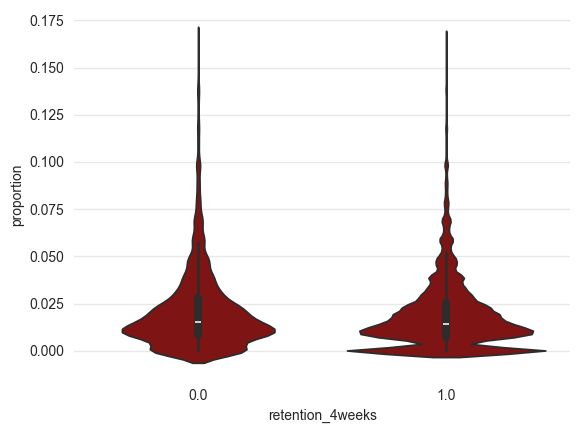

In [199]:
sns.violinplot(data=df[(df['proportion'] < df['proportion'].quantile(0.999))], x='retention_4weeks', y='proportion', color='#910202')

In [200]:
df.groupby('retention_2weeks').agg({'proportion': 'mean'})

,proportion
retention_2weeks,
0.0,0.017273
1.0,0.015950


In [201]:
stats.levene(df[(df['retention_2weeks'] == 1)]['proportion'], df[(df['retention_2weeks'] == 0)]['proportion'])

LeveneResult(statistic=np.float64(242.86339145763964), pvalue=np.float64(9.757744755091072e-55))

In [202]:
stats.ttest_ind(df[(df['retention_2weeks'] == 1)]['proportion'], df[(df['retention_2weeks'] == 0)]['proportion'], equal_var=False)

TtestResult(statistic=np.float64(-14.808815089002978), pvalue=np.float64(1.441138428937915e-49), df=np.float64(105549.26502678003))

In [203]:
df.groupby('retention_4weeks').agg({'proportion': 'mean'})

,proportion
retention_4weeks,
0.0,0.022148
1.0,0.019507


In [204]:
stats.levene(df[(df['retention_4weeks'] == 1)]['proportion'], df[(df['retention_4weeks'] == 0)]['proportion'])

LeveneResult(statistic=np.float64(129.48475344126618), pvalue=np.float64(5.4117400045559364e-30))

In [205]:
stats.ttest_ind(df[(df['retention_4weeks'] == 1)]['proportion'], df[(df['retention_4weeks'] == 0)]['proportion'], equal_var=False)

TtestResult(statistic=np.float64(-12.840838853677942), pvalue=np.float64(1.4152141273033558e-37), df=np.float64(18012.530538912688))

<Axes: xlabel='retention_2weeks', ylabel='proportion'>

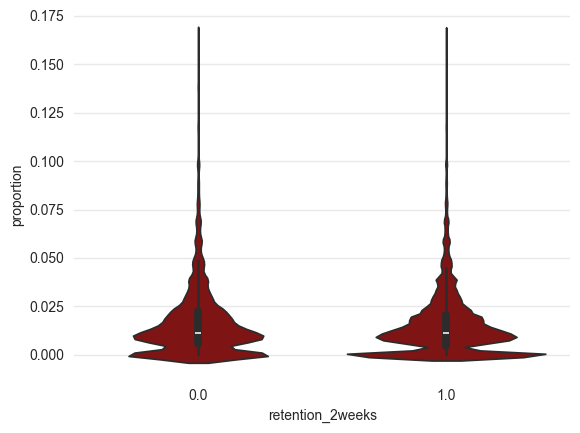

In [206]:
sns.violinplot(data=df[(df['proportion'] < df['proportion'].quantile(0.999))], x='retention_2weeks', y='proportion', color='#910202')

<Axes: xlabel='retention_4weeks', ylabel='proportion'>

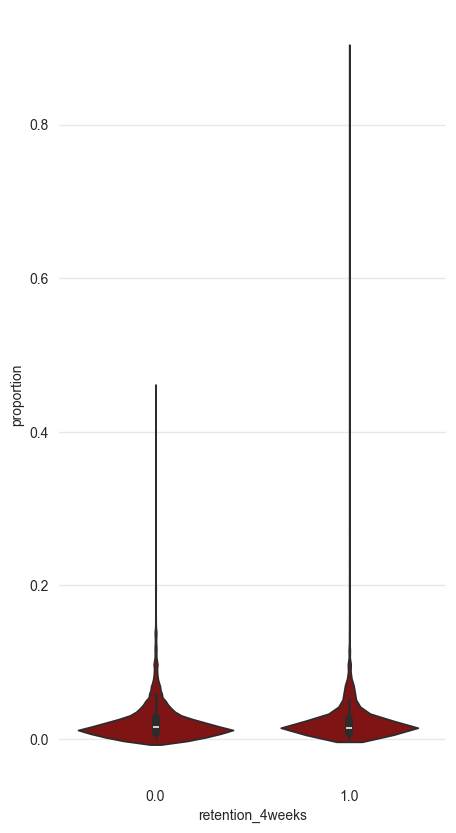

In [207]:
plt.figure(figsize=(5, 10))
sns.violinplot(data=df, x='retention_4weeks', y='proportion', color='#910202')

<Axes: xlabel='retention_4weeks', ylabel='proportion'>

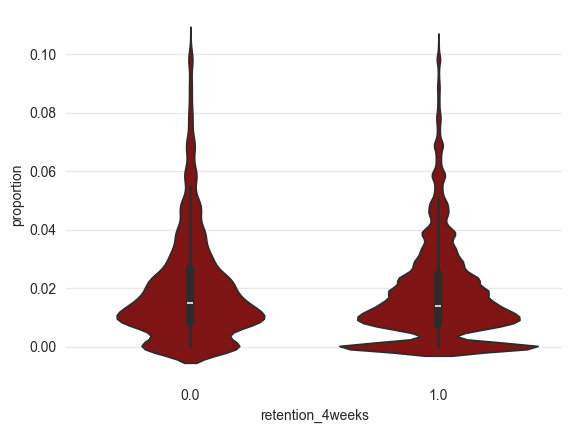

In [208]:
sns.violinplot(data=df[(df['proportion'] < df['proportion'].quantile(0.995))], x='retention_4weeks', y='proportion', color='#910202')

<Axes: xlabel='retention_2weeks', ylabel='proportion'>

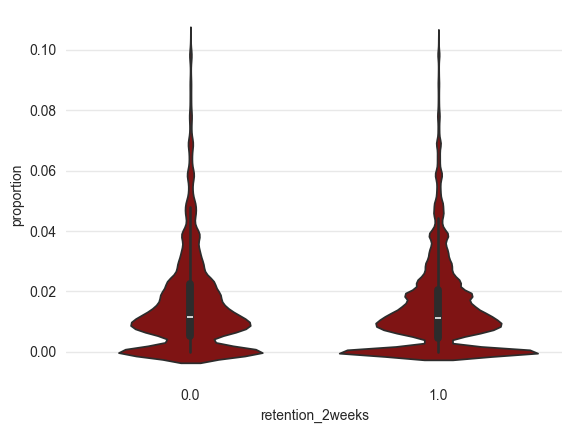

In [209]:
sns.violinplot(data=df[(df['proportion'] < df['proportion'].quantile(0.995))], x='retention_2weeks', y='proportion', color='#910202')

In [210]:
df

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,next_week,weeks_to_next,proportion,retention_4weeks,retention_2weeks
414990,2025-04-06 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,38.59,2024-05-07,...,NaN,NaN,2196.40,56.916300,2024-05-07,2025-04-20 21:00:00+00:00,2.0,0.013203,1.0,1.0
31311,2025-04-20 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,2196.40,54.910000,2024-05-07,2025-05-11 21:00:00+00:00,3.0,0.013203,1.0,0.0
410692,2025-05-11 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,2196.40,54.910000,2024-05-07,2025-05-18 21:00:00+00:00,1.0,0.008651,NaN,1.0
133901,2025-05-18 21:00:00+00:00,12103,0,573.25,1,No Subscription,0.0,ANDROID,9.98,2024-05-07,...,NaN,NaN,573.25,57.439880,2024-05-07,2025-05-25 21:00:00+00:00,1.0,0.000000,NaN,NaN
383760,2025-05-25 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,2196.40,54.910000,2024-05-07,NaT,NaN,0.008651,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407410,2025-05-04 21:00:00+00:00,1356117601,19,1103.04,1,Pro,4.0,ANDROID,19.95,2022-06-23,...,NaN,NaN,1103.04,55.290226,2022-06-23,2025-05-25 21:00:00+00:00,3.0,0.017225,NaN,0.0
40139,2025-05-25 21:00:00+00:00,1356117601,19,626.48,1,Pro,4.0,ANDROID,11.29,2022-06-23,...,NaN,NaN,626.48,55.489814,2022-06-23,NaT,NaN,0.030328,NaN,NaN
234499,2025-04-13 21:00:00+00:00,1356182120,59,999.00,1,No Subscription,0.0,IOS,17.38,2022-03-31,...,NaN,NaN,999.00,57.479862,2022-03-31,2025-04-27 21:00:00+00:00,2.0,0.059059,1.0,1.0
38659,2025-04-27 21:00:00+00:00,1356182120,0,999.28,1,No Subscription,0.0,IOS,17.40,2022-03-31,...,NaN,NaN,999.28,57.429885,2022-03-31,2025-05-11 21:00:00+00:00,2.0,0.000000,1.0,1.0


In [211]:
group1 = df[df['retention_4weeks'] == 1]['proportion'].dropna()
group0 = df[df['retention_4weeks'] == 0]['proportion'].dropna()

In [212]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values(["party_rk", "week"]).copy()

df_sorted["prev_fee_user"] = (
    df_sorted.groupby("party_rk")["service_fee_amt"].shift(1)
)

df_sorted["changed_vs_user_prev"] = (
    df_sorted["prev_fee_user"].notna()
    & (df_sorted["service_fee_amt"] != df_sorted["prev_fee_user"])
)

weekly_cnt = (
    df_sorted.groupby("week")["changed_vs_user_prev"].sum()
)

weekly_denom = (
    df_sorted.groupby("week")["prev_fee_user"]
    .apply(lambda x: x.notna().sum())
)

weekly_share = weekly_cnt / weekly_denom


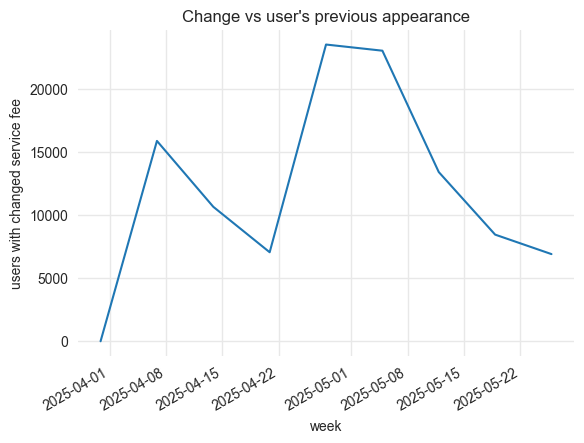

In [213]:
plt.figure()
weekly_cnt.sort_index().plot()
plt.xlabel("week")
plt.ylabel("users with changed service fee")
plt.title("Change vs user's previous appearance")
plt.show()


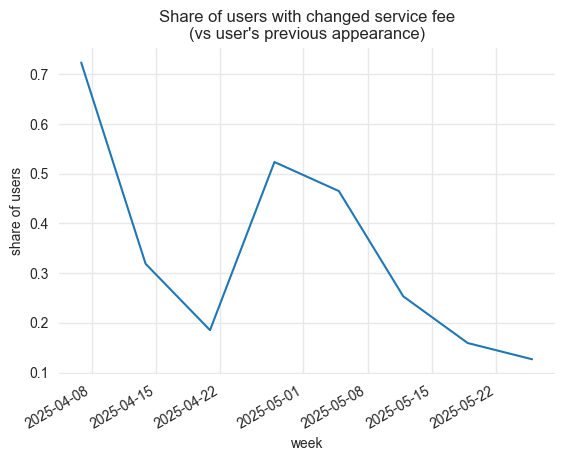

In [214]:
plt.figure()
weekly_share.sort_index().plot()
plt.xlabel("week")
plt.ylabel("share of users")
plt.title("Share of users with changed service fee\n(vs user's previous appearance)")
plt.show()


In [215]:
weeks = sorted(df_sorted["week"].unique())
week_to_prev = {weeks[i]: weeks[i-1] for i in range(1, len(weeks))}

df_sorted["prev_week"] = df_sorted["week"].map(week_to_prev)

prev_df = df_sorted[["party_rk", "week", "service_fee_amt"]].copy()
prev_df.columns = ["party_rk", "prev_week", "prev_week_fee"]

df_cmp = df_sorted.merge(
    prev_df,
    on=["party_rk", "prev_week"],
    how="left"
)

df_cmp["changed_vs_dataset_prev"] = (
    df_cmp["prev_week_fee"].notna()
    & (df_cmp["service_fee_amt"] != df_cmp["prev_week_fee"])
)

weekly_cnt_ds = (
    df_cmp.groupby("week")["changed_vs_dataset_prev"].sum()
)

weekly_denom_ds = (
    df_cmp.groupby("week")["prev_week_fee"]
    .apply(lambda x: x.notna().sum())
)

weekly_share_ds = weekly_cnt_ds / weekly_denom_ds


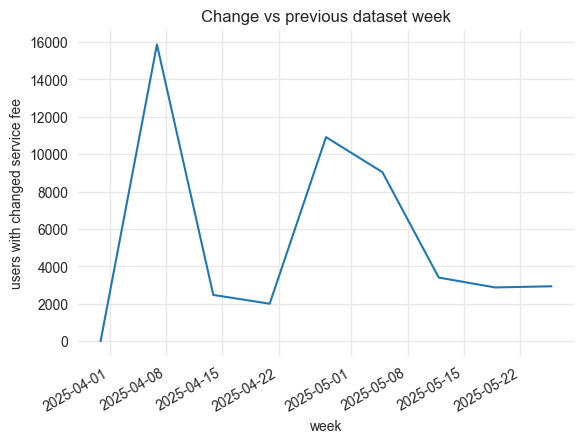

In [216]:
plt.figure()
weekly_cnt_ds.sort_index().plot()
plt.xlabel("week")
plt.ylabel("users with changed service fee")
plt.title("Change vs previous dataset week")
plt.show()


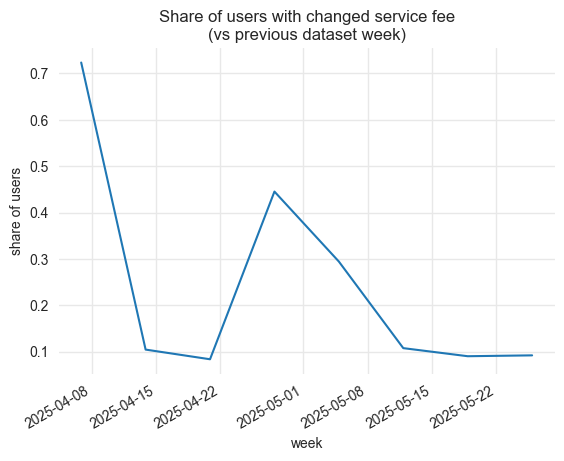

In [217]:
plt.figure()
weekly_share_ds.sort_index().plot()
plt.xlabel("week")
plt.ylabel("share of users")
plt.title("Share of users with changed service fee\n(vs previous dataset week)")
plt.show()


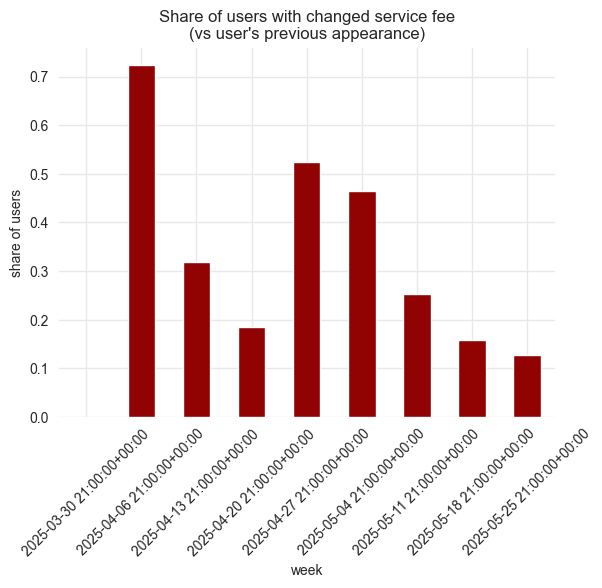

In [218]:
plt.figure()
weekly_share.sort_index().plot(kind="bar", color='#910202')
plt.xlabel("week")
plt.ylabel("share of users")
plt.title(
    "Share of users with changed service fee\n"
    "(vs user's previous appearance)"
)
plt.xticks(rotation=45)
plt.show()


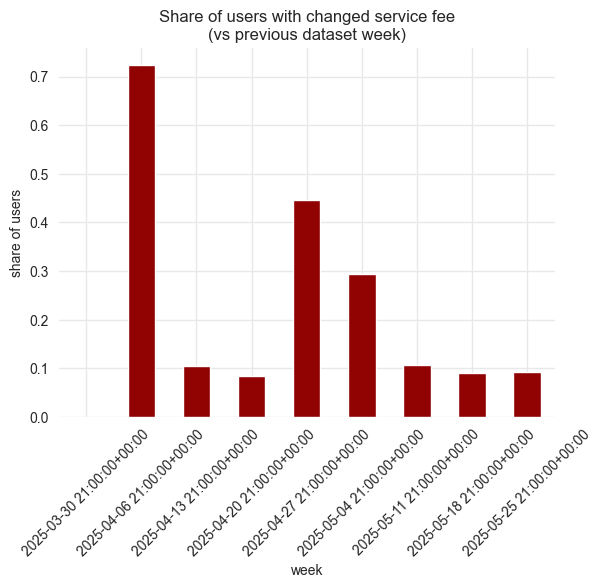

In [219]:
plt.figure()
weekly_share_ds.sort_index().plot(kind="bar", color='#910202')
plt.xlabel("week")
plt.ylabel("share of users")
plt.title(
    "Share of users with changed service fee\n"
    "(vs previous dataset week)"
)
plt.xticks(rotation=45)
plt.show()


In [220]:
df

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,next_week,weeks_to_next,proportion,retention_4weeks,retention_2weeks
414990,2025-04-06 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,38.59,2024-05-07,...,NaN,NaN,2196.40,56.916300,2024-05-07,2025-04-20 21:00:00+00:00,2.0,0.013203,1.0,1.0
31311,2025-04-20 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,2196.40,54.910000,2024-05-07,2025-05-11 21:00:00+00:00,3.0,0.013203,1.0,0.0
410692,2025-05-11 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,2196.40,54.910000,2024-05-07,2025-05-18 21:00:00+00:00,1.0,0.008651,NaN,1.0
133901,2025-05-18 21:00:00+00:00,12103,0,573.25,1,No Subscription,0.0,ANDROID,9.98,2024-05-07,...,NaN,NaN,573.25,57.439880,2024-05-07,2025-05-25 21:00:00+00:00,1.0,0.000000,NaN,NaN
383760,2025-05-25 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,2196.40,54.910000,2024-05-07,NaT,NaN,0.008651,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407410,2025-05-04 21:00:00+00:00,1356117601,19,1103.04,1,Pro,4.0,ANDROID,19.95,2022-06-23,...,NaN,NaN,1103.04,55.290226,2022-06-23,2025-05-25 21:00:00+00:00,3.0,0.017225,NaN,0.0
40139,2025-05-25 21:00:00+00:00,1356117601,19,626.48,1,Pro,4.0,ANDROID,11.29,2022-06-23,...,NaN,NaN,626.48,55.489814,2022-06-23,NaT,NaN,0.030328,NaN,NaN
234499,2025-04-13 21:00:00+00:00,1356182120,59,999.00,1,No Subscription,0.0,IOS,17.38,2022-03-31,...,NaN,NaN,999.00,57.479862,2022-03-31,2025-04-27 21:00:00+00:00,2.0,0.059059,1.0,1.0
38659,2025-04-27 21:00:00+00:00,1356182120,0,999.28,1,No Subscription,0.0,IOS,17.40,2022-03-31,...,NaN,NaN,999.28,57.429885,2022-03-31,2025-05-11 21:00:00+00:00,2.0,0.000000,1.0,1.0


<Axes: xlabel='orders_cnt', ylabel='count'>

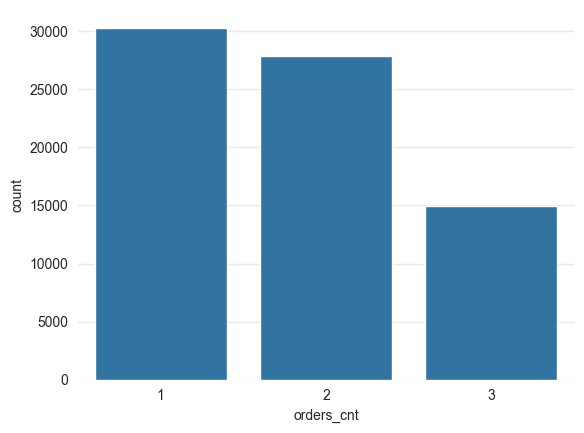

In [221]:
sns.countplot(x=df[(df['week'] < '2025-04-27 21:00:00+00:00') & (df['week'] >= '2025-04-06 21:00:00+00:00')].groupby('party_rk').agg({'orders_cnt': 'count'})['orders_cnt'])

In [222]:
df_3weeks_agged = df[(df['week'] < '2025-04-27 21:00:00+00:00') & (df['week'] >= '2025-04-06 21:00:00+00:00')].groupby('party_rk', as_index=False).agg({'orders_cnt': 'count'})

In [223]:
df[(df['week'] < '2025-04-27 21:00:00+00:00') & (df['week'] >= '2025-04-06 21:00:00+00:00')].groupby('party_rk', as_index=False).agg({'orders_cnt': 'count'})['orders_cnt'].value_counts(normalize=True)

orders_cnt
1    0.414931
2    0.380969
3    0.204100
Name: proportion, dtype: float64

In [224]:
df_3weeks_agged

,party_rk,orders_cnt
0,12103,2
1,14045,3
2,15150,1
3,17433,1
4,22290,3
...,...,...
73077,1355782205,1
73078,1355859237,3
73079,1355917234,3
73080,1356117601,1


In [225]:
idiots = list(df_3weeks_agged[df_3weeks_agged['orders_cnt'] != 1]['party_rk'])

In [226]:
df[(df['week'] < '2025-04-27 21:00:00+00:00') & (df['week'] >= '2025-04-06 21:00:00+00:00') & (df['party_rk'].isin(idiots))]

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,next_week,weeks_to_next,proportion,retention_4weeks,retention_2weeks
414990,2025-04-06 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,38.59,2024-05-07,...,NaN,NaN,2196.400,56.916300,2024-05-07,2025-04-20 21:00:00+00:00,2.0,0.013203,1.0,1.0
31311,2025-04-20 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,2196.400,54.910000,2024-05-07,2025-05-11 21:00:00+00:00,3.0,0.013203,1.0,0.0
193571,2025-04-06 21:00:00+00:00,14045,23,2553.58,1,Pro,0.0,ANDROID,41.28,2023-07-08,...,NaN,NaN,2553.580,61.859981,2023-07-08,2025-04-13 21:00:00+00:00,1.0,0.009007,1.0,1.0
408953,2025-04-13 21:00:00+00:00,14045,69,2398.93,1,Pro,0.0,ANDROID,38.78,2023-07-08,...,NaN,NaN,2398.930,61.859979,2023-07-08,2025-04-20 21:00:00+00:00,1.0,0.028763,1.0,1.0
396756,2025-04-20 21:00:00+00:00,14045,69,4427.30,2,Pro,0.0,ANDROID,71.80,2023-07-08,...,NaN,NaN,2213.650,61.661560,2023-07-08,2025-04-27 21:00:00+00:00,1.0,0.031170,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67354,2025-04-13 21:00:00+00:00,1355859237,0,1199.40,2,No Subscription,0.0,IOS,21.49,2025-03-24,...,NaN,NaN,599.700,55.812006,2025-03-24,2025-04-20 21:00:00+00:00,1.0,0.000000,1.0,1.0
338078,2025-04-20 21:00:00+00:00,1355859237,0,1999.30,4,No Subscription,0.0,IOS,35.14,2025-03-24,...,NaN,NaN,499.825,56.895276,2025-03-24,2025-04-27 21:00:00+00:00,1.0,0.000000,1.0,1.0
347450,2025-04-06 21:00:00+00:00,1355917234,0,2635.69,1,Premium,3.0,WEBVIEW_IOS,41.08,2024-04-19,...,NaN,NaN,2635.690,64.159932,2024-04-19,2025-04-13 21:00:00+00:00,1.0,0.000000,1.0,1.0
352539,2025-04-13 21:00:00+00:00,1355917234,99,5195.68,2,Premium,3.0,WEBVIEW_IOS,80.98,2024-04-19,...,NaN,NaN,2597.840,64.160040,2024-04-19,2025-04-20 21:00:00+00:00,1.0,0.038109,1.0,1.0


In [227]:
df[(df['week'] < '2025-04-27 21:00:00+00:00') & (df['week'] >= '2025-04-06 21:00:00+00:00') & (df['party_rk'].isin(idiots))].groupby('party_rk').agg({'service_fee_amt': 'nunique'})

,service_fee_amt
party_rk,
12103,1
14045,2
22290,1
44827,1
196706,1
...,...
1355316586,1
1355389043,1
1355764044,1


<Axes: xlabel='service_fee_amt', ylabel='count'>

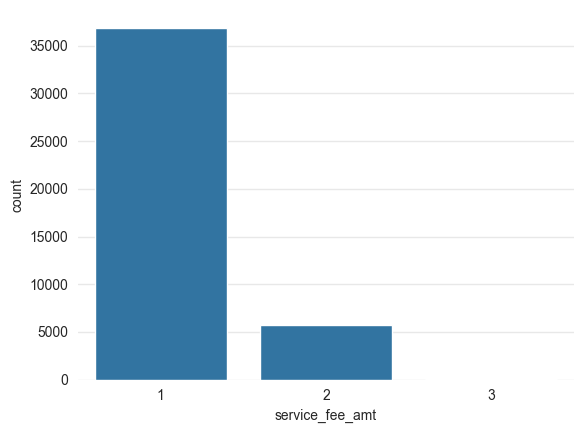

In [228]:
sns.countplot(x=df[(df['week'] < '2025-04-27 21:00:00+00:00') & (df['week'] >= '2025-04-06 21:00:00+00:00') & (df['party_rk'].isin(idiots))].groupby('party_rk').agg({'service_fee_amt': 'nunique'})['service_fee_amt'])

<Axes: xlabel='service_fee_amt', ylabel='count'>

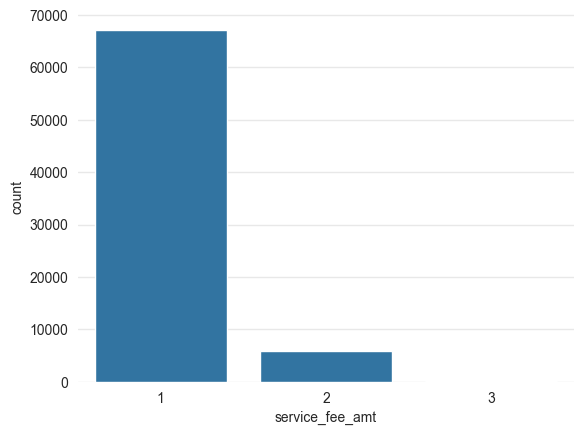

In [229]:
sns.countplot(x=df[(df['week'] < '2025-04-27 21:00:00+00:00') & (df['week'] >= '2025-04-06 21:00:00+00:00')].groupby('party_rk').agg({'service_fee_amt': 'nunique'})['service_fee_amt'])

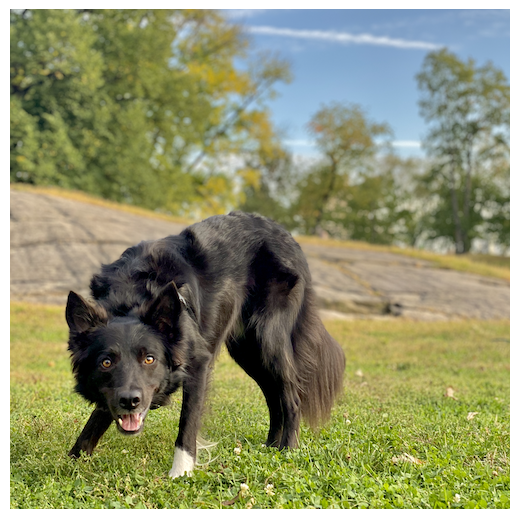

In [230]:
sns.dogplot()

In [231]:
df['change2'] = df.groupby('party_rk')['service_fee_amt'] \
                  .transform(lambda x: x.diff().fillna(pd.NA))

# Превращаем в 1 / 0 / -1
df['change2'] = np.sign(df['change2']).astype('Int64')  # Int64 сохраняет NaN

In [232]:
df['change2_cat'] = df['change2'].astype('category')

In [233]:
l = df.groupby('party_rk', as_index=False).agg({'orders_cnt': 'mean'})

In [234]:
goodguys = list(l[l['orders_cnt'] == 1]['party_rk'])

In [235]:
df[df['party_rk'].isin(goodguys)]

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,mean_price,meanperliter,fisrt_order_date,next_week,weeks_to_next,proportion,retention_4weeks,retention_2weeks,change2,change2_cat
414990,2025-04-06 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,38.59,2024-05-07,...,2196.40,56.916300,2024-05-07,2025-04-20 21:00:00+00:00,2.0,0.013203,1.0,1.0,<NA>,NaN
31311,2025-04-20 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,2196.40,54.910000,2024-05-07,2025-05-11 21:00:00+00:00,3.0,0.013203,1.0,0.0,0,0
410692,2025-05-11 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,2196.40,54.910000,2024-05-07,2025-05-18 21:00:00+00:00,1.0,0.008651,NaN,1.0,-1,-1
133901,2025-05-18 21:00:00+00:00,12103,0,573.25,1,No Subscription,0.0,ANDROID,9.98,2024-05-07,...,573.25,57.439880,2024-05-07,2025-05-25 21:00:00+00:00,1.0,0.000000,NaN,NaN,-1,-1
383760,2025-05-25 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,2196.40,54.910000,2024-05-07,NaT,NaN,0.008651,NaN,NaN,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336880,2025-05-11 21:00:00+00:00,1355793619,19,2322.70,1,No Subscription,0.0,ANDROID,27.09,2024-11-08,...,2322.70,85.740126,2024-11-08,2025-05-18 21:00:00+00:00,1.0,0.008180,NaN,1.0,0,0
40169,2025-05-18 21:00:00+00:00,1355793619,19,1950.59,1,No Subscription,0.0,ANDROID,22.75,2024-11-08,...,1950.59,85.740220,2024-11-08,NaT,NaN,0.009741,NaN,NaN,0,0
234499,2025-04-13 21:00:00+00:00,1356182120,59,999.00,1,No Subscription,0.0,IOS,17.38,2022-03-31,...,999.00,57.479862,2022-03-31,2025-04-27 21:00:00+00:00,2.0,0.059059,1.0,1.0,<NA>,NaN
38659,2025-04-27 21:00:00+00:00,1356182120,0,999.28,1,No Subscription,0.0,IOS,17.40,2022-03-31,...,999.28,57.429885,2022-03-31,2025-05-11 21:00:00+00:00,2.0,0.000000,1.0,1.0,-1,-1


In [236]:
df['prev_gmv'] = (
    df.groupby('party_rk')['gmv']
      .shift(1)
)


In [237]:
df

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,meanperliter,fisrt_order_date,next_week,weeks_to_next,proportion,retention_4weeks,retention_2weeks,change2,change2_cat,prev_gmv
414990,2025-04-06 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,38.59,2024-05-07,...,56.916300,2024-05-07,2025-04-20 21:00:00+00:00,2.0,0.013203,1.0,1.0,<NA>,NaN,NaN
31311,2025-04-20 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,54.910000,2024-05-07,2025-05-11 21:00:00+00:00,3.0,0.013203,1.0,0.0,0,0,2196.40
410692,2025-05-11 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,54.910000,2024-05-07,2025-05-18 21:00:00+00:00,1.0,0.008651,NaN,1.0,-1,-1,2196.40
133901,2025-05-18 21:00:00+00:00,12103,0,573.25,1,No Subscription,0.0,ANDROID,9.98,2024-05-07,...,57.439880,2024-05-07,2025-05-25 21:00:00+00:00,1.0,0.000000,NaN,NaN,-1,-1,2196.40
383760,2025-05-25 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,54.910000,2024-05-07,NaT,NaN,0.008651,NaN,NaN,1,1,573.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407410,2025-05-04 21:00:00+00:00,1356117601,19,1103.04,1,Pro,4.0,ANDROID,19.95,2022-06-23,...,55.290226,2022-06-23,2025-05-25 21:00:00+00:00,3.0,0.017225,NaN,0.0,-1,-1,1402.99
40139,2025-05-25 21:00:00+00:00,1356117601,19,626.48,1,Pro,4.0,ANDROID,11.29,2022-06-23,...,55.489814,2022-06-23,NaT,NaN,0.030328,NaN,NaN,0,0,1103.04
234499,2025-04-13 21:00:00+00:00,1356182120,59,999.00,1,No Subscription,0.0,IOS,17.38,2022-03-31,...,57.479862,2022-03-31,2025-04-27 21:00:00+00:00,2.0,0.059059,1.0,1.0,<NA>,NaN,NaN
38659,2025-04-27 21:00:00+00:00,1356182120,0,999.28,1,No Subscription,0.0,IOS,17.40,2022-03-31,...,57.429885,2022-03-31,2025-05-11 21:00:00+00:00,2.0,0.000000,1.0,1.0,-1,-1,999.00


In [238]:
df['gmv_diff'] = df['gmv'] - df['prev_gmv']

In [239]:
goods = df[df['party_rk'].isin(goodguys)]

<Axes: xlabel='change2', ylabel='gmv_diff'>

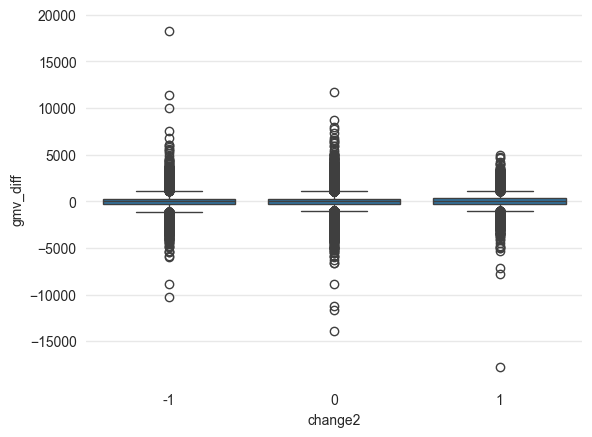

In [240]:
sns.boxplot(data=df[df['party_rk'].isin(goodguys)], x='change2', y='gmv_diff')

<Axes: xlabel='gmv_diff', ylabel='change2_cat'>

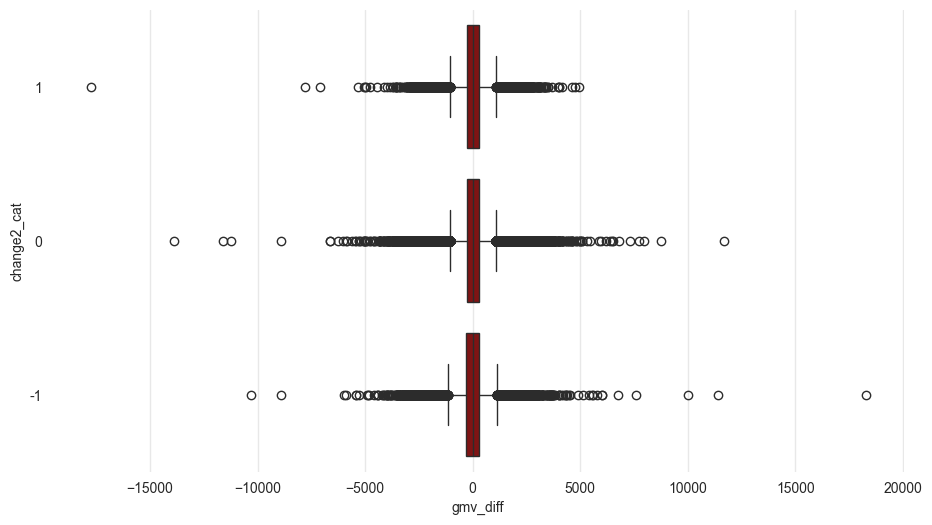

In [241]:
df['change2_cat'] = df['change2'].astype('category')
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df[df['party_rk'].isin(goodguys)],
    x='gmv_diff',
    y='change2_cat',
    order=[1, 0, -1], color='#910202'
)


In [242]:
goods2 = df[(df['party_rk'].isin(goodguys)) & (df['week'] != '2025-04-27 21:00:00+00:00') & (df['week'] != '2025-04-06 21:00:00+00:00')]

In [243]:
stats.levene(goods2[goods2['change2_cat'] == 0]['gmv_diff'], goods[goods['change2_cat'] == 1]['gmv_diff'])

LeveneResult(statistic=np.float64(4.087000256852793), pvalue=np.float64(0.04321714222829659))

In [244]:
stats.ttest_ind(goods2[goods2['change2_cat'] == 0]['gmv_diff'], goods[goods['change2_cat'] == 1]['gmv_diff'], equal_var=False)

TtestResult(statistic=np.float64(-1.6848671388927423), pvalue=np.float64(0.0920281505900838), df=np.float64(22379.87804010354))

In [245]:
stats.levene(goods2[goods2['change2_cat'] == 0]['gmv_diff'], goods[goods['change2_cat'] == -1]['gmv_diff'])

LeveneResult(statistic=np.float64(67.79472856233534), pvalue=np.float64(1.834334025250908e-16))

In [246]:
stats.ttest_ind(goods2[goods2['change2_cat'] == 0]['gmv_diff'], goods[goods['change2_cat'] == -1]['gmv_diff'], equal_var=False, alternative='greater')

TtestResult(statistic=np.float64(3.1602356383511543), pvalue=np.float64(0.0007886412761812818), df=np.float64(54204.2169092549))

In [247]:
stats.levene(goods2[goods2['change2_cat'] == 1]['gmv_diff'], goods[goods['change2_cat'] == -1]['gmv_diff'])

LeveneResult(statistic=np.float64(8.40835734571354), pvalue=np.float64(0.0037369500137662513))

In [248]:
stats.ttest_ind(goods2[goods2['change2_cat'] == 1]['gmv_diff'], goods[goods['change2_cat'] == -1]['gmv_diff'], equal_var=False, alternative='greater')

TtestResult(statistic=np.float64(2.232677960238615), pvalue=np.float64(0.012790912273065143), df=np.float64(18947.366698663267))

In [249]:
stats.f_oneway(goods[goods['change2_cat'] == 0]['gmv_diff'], goods[goods['change2_cat'] == 1]['gmv_diff'], goods[goods['change2_cat'] == -1]['gmv_diff'])

F_onewayResult(statistic=np.float64(8.391966891393423), pvalue=np.float64(0.00022680172937267565))

In [250]:
stats.f_oneway(goods2[goods2['change2_cat'] == 0]['gmv_diff'], goods2[goods2['change2_cat'] == 1]['gmv_diff'], goods2[goods2['change2_cat'] == -1]['gmv_diff'])

F_onewayResult(statistic=np.float64(6.425422808402578), pvalue=np.float64(0.001620463821671094))

In [251]:
stats.kruskal(goods[goods['change2_cat'] == 0]['gmv_diff'], goods[goods['change2_cat'] == 1]['gmv_diff'], goods[goods['change2_cat'] == -1]['gmv_diff'])

KruskalResult(statistic=np.float64(30.036861060424414), pvalue=np.float64(3.0031601595007464e-07))

C:\Users\darak\AppData\Local\Temp\ipykernel_44988\3875856452.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Группа', y='Retention', data=data, palette=colors)


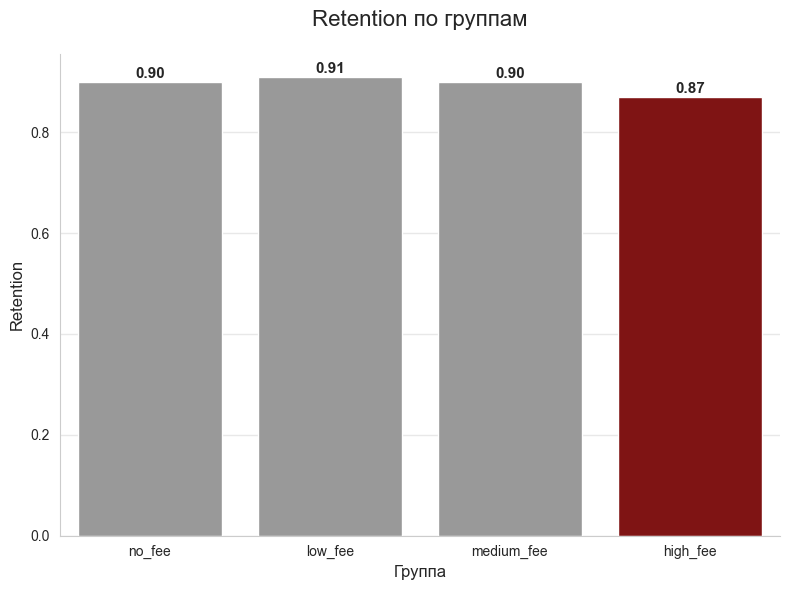

In [252]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Данные из твоей таблицы
data = {
    'Группа': ['no_fee', 'low_fee', 'medium_fee', 'high_fee'],
    'Retention': [0.90, 0.91, 0.90, 0.87]
}

data = pd.DataFrame(data)

# Цвета: серый для всех, кроме high_fee
colors = ['#999999', '#999999', '#999999', '#910202']

# Создаём график
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Группа', y='Retention', data=data, palette=colors)

# Настройки
sns.set_style("whitegrid")
plt.title('Retention по группам', fontsize=16, pad=20)
plt.ylabel('Retention', fontsize=12)
plt.xlabel('Группа', fontsize=12)

# Добавляем значения наверх столбцов
for i, bar in enumerate(ax.patches):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.002, 
            f'{data["Retention"][i]:.2f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Убираем лишние рамки
sns.despine()

plt.tight_layout()
plt.show()

In [253]:
df

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,fisrt_order_date,next_week,weeks_to_next,proportion,retention_4weeks,retention_2weeks,change2,change2_cat,prev_gmv,gmv_diff
414990,2025-04-06 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,38.59,2024-05-07,...,2024-05-07,2025-04-20 21:00:00+00:00,2.0,0.013203,1.0,1.0,<NA>,NaN,NaN,NaN
31311,2025-04-20 21:00:00+00:00,12103,29,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,2024-05-07,2025-05-11 21:00:00+00:00,3.0,0.013203,1.0,0.0,0,0,2196.40,0.00
410692,2025-05-11 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,2024-05-07,2025-05-18 21:00:00+00:00,1.0,0.008651,NaN,1.0,-1,-1,2196.40,0.00
133901,2025-05-18 21:00:00+00:00,12103,0,573.25,1,No Subscription,0.0,ANDROID,9.98,2024-05-07,...,2024-05-07,2025-05-25 21:00:00+00:00,1.0,0.000000,NaN,NaN,-1,-1,2196.40,-1623.15
383760,2025-05-25 21:00:00+00:00,12103,19,2196.40,1,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,2024-05-07,NaT,NaN,0.008651,NaN,NaN,1,1,573.25,1623.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407410,2025-05-04 21:00:00+00:00,1356117601,19,1103.04,1,Pro,4.0,ANDROID,19.95,2022-06-23,...,2022-06-23,2025-05-25 21:00:00+00:00,3.0,0.017225,NaN,0.0,-1,-1,1402.99,-299.95
40139,2025-05-25 21:00:00+00:00,1356117601,19,626.48,1,Pro,4.0,ANDROID,11.29,2022-06-23,...,2022-06-23,NaT,NaN,0.030328,NaN,NaN,0,0,1103.04,-476.56
234499,2025-04-13 21:00:00+00:00,1356182120,59,999.00,1,No Subscription,0.0,IOS,17.38,2022-03-31,...,2022-03-31,2025-04-27 21:00:00+00:00,2.0,0.059059,1.0,1.0,<NA>,NaN,NaN,NaN
38659,2025-04-27 21:00:00+00:00,1356182120,0,999.28,1,No Subscription,0.0,IOS,17.40,2022-03-31,...,2022-03-31,2025-05-11 21:00:00+00:00,2.0,0.000000,1.0,1.0,-1,-1,999.00,0.28


In [256]:
df[df['week'] >= '2025-04-27 21:00:00+00:00'].groupby('service_fee_amt').agg({'retention_2weeks': 'mean'})

,retention_2weeks
service_fee_amt,
0,0.796120
19,0.821169
23,0.785123
29,0.759679
39,0.725454
49,0.781316
59,0.769231
69,0.785673


In [266]:
df['age']

414990   NaN
31311    NaN
410692   NaN
133901   NaN
383760   NaN
          ..
407410   NaN
40139    NaN
234499   NaN
38659    NaN
239462   NaN
Name: age, Length: 448035, dtype: float64

In [272]:
df[(df['children_cnt'] >= 1) & (df['age'].isna() == False)].groupby('party_rk').agg({'age': 'mean'}).max()

age    72.0
dtype: float64

In [273]:
df[(df['children_cnt'] >= 1)]

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,fisrt_order_date,next_week,weeks_to_next,proportion,retention_4weeks,retention_2weeks,change2,change2_cat,prev_gmv,gmv_diff
270356,2025-05-04 21:00:00+00:00,28868,0,1048.24,2,Pro,4.0,WEBVIEW_IOS,17.42,2024-05-14,...,2024-05-14,2025-05-18 21:00:00+00:00,2.0,0.000000,NaN,1.0,<NA>,NaN,NaN,NaN
365608,2025-05-18 21:00:00+00:00,28868,0,798.99,1,Pro,4.0,WEBVIEW_IOS,13.29,2024-05-14,...,2024-05-14,2025-05-25 21:00:00+00:00,1.0,0.000000,NaN,NaN,0,0,1048.24,-249.25
41661,2025-05-25 21:00:00+00:00,28868,19,948.26,2,Pro,4.0,WEBVIEW_IOS,15.70,2024-05-14,...,2024-05-14,NaT,NaN,0.040073,NaN,NaN,1,1,798.99,149.27
306724,2025-04-27 21:00:00+00:00,34780,19,1969.33,1,Pro,4.0,ANDROID,31.98,2024-10-16,...,2024-10-16,2025-05-04 21:00:00+00:00,1.0,0.009648,1.0,1.0,<NA>,NaN,NaN,NaN
178576,2025-05-04 21:00:00+00:00,34780,19,2344.49,1,Pro,4.0,ANDROID,38.34,2024-10-16,...,2024-10-16,2025-05-11 21:00:00+00:00,1.0,0.008104,NaN,1.0,0,0,1969.33,375.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124311,2025-05-18 21:00:00+00:00,1218587173,0,3515.91,3,No Subscription,0.0,ANDROID,61.72,2022-09-12,...,2022-09-12,2025-05-25 21:00:00+00:00,1.0,0.000000,NaN,NaN,0,0,1718.73,1797.18
40004,2025-05-25 21:00:00+00:00,1218587173,0,1424.43,1,No Subscription,0.0,ANDROID,24.99,2022-09-12,...,2022-09-12,NaT,NaN,0.000000,NaN,NaN,0,0,3515.91,-2091.48
380116,2025-04-27 21:00:00+00:00,1225376413,19,2406.03,1,Pro,0.0,ANDROID,38.27,2025-05-04,...,2025-05-04,2025-05-04 21:00:00+00:00,1.0,0.007897,1.0,1.0,<NA>,NaN,NaN,NaN
8699,2025-05-04 21:00:00+00:00,1225376413,19,5700.87,2,Pro,0.0,ANDROID,91.13,2025-05-04,...,2025-05-04,2025-05-11 21:00:00+00:00,1.0,0.006666,NaN,1.0,0,0,2406.03,3294.84
